<a href="https://colab.research.google.com/github/ramiltrinidad-ctrl/maida/blob/main/numpy_PCA(rumpy_answer).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Application of Numpy: PCA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.testing import assert_allclose

In [ ]:
np.set_printoptions(suppress=True,precision=6)
np.random.seed(12345)

## Introduction: Multi-dimensional Data

It is often the case that you will be working with data in multiple dimensions.

For example, if you have the historical price data of 100 stocks, each tick of time would give you a 100-dimensional data point.

Very generally - many dimensions are inconvenient to work with.  
Not only do they slow down all of your computations, they tend to obfuscate the important relationships in the data.   
Thus, it is a good idea to try and reduce the number of dimensions under consideration and focus on the most important ones.

**Principal component analysis (PCA)** is one such way to quantitatively find the most important relationships between the data.

### A Simplified Example: 2-D Gaussians

Consider a set of 10000 data points in 2-dimensions.

You can imagine each point is tick data, and the dimensions are price (changes) of $2$ stocks, say *Apple* and *Microsoft*, at that instant.  
Each series is distributed according to its own Gaussian distribution, centered at $0$, and they are **completely independent** for now.

We can generate this with numpy's `multivariate_normal` command with vanishing covariance (off-diagonal) terms.  
WLOG, I am also taking one of the variances to be larger than the other.

Then observe the resulting distributions.

In [ ]:
N = 10**5
mean = np.array([0, 0])
cov = np.array([[20, 0],
                [0, 2]])

pts = np.random.multivariate_normal(mean, cov, size=N)

In [ ]:
# Bunch of function definitions (would put this in module then import)
def standard_plot(
    fig,
    axs,
    pts,
    facecolor='b',
    edgecolor='b',
    nbins=np.linspace(-200, 200, 200+1),
    salpha=0.002,  # minimum possible
    alpha=0.2,
):
    """Standard plotter for this notebook"""

    axs[0].scatter(pts[:, 0],
                   pts[:, 1],
                   facecolor=facecolor,
                   edgecolor=None,
                   s=1,
                   alpha=salpha
                   )

    axs[1].hist(pts[:, 0],
                bins=nbins,
                alpha=alpha,
                facecolor=facecolor,
                edgecolor=edgecolor
                )
    axs[2].hist(pts[:, 1],
                bins=nbins,
                alpha=alpha,
                facecolor=facecolor,
                edgecolor=edgecolor
                )


def format_plot(xlim, ylim, hist_y):
    """Format plot axes"""

    axs[0].axis('equal')
    axs[0].grid()

    axs[1].set_xlim(-xlim, xlim)
    axs[2].set_xlim(-ylim, ylim)
    axs[1].set_ylim(0, hist_y)
    axs[2].set_ylim(0, hist_y)

    axs[0].set_xlabel('x')
    axs[0].set_ylabel('y')
    axs[0].set_title('x-y scatter')
    axs[1].set_xlabel('x')
    axs[1].set_title('x-Histogram')
    axs[2].set_xlabel('y')
    axs[2].set_title('y-Histogram')


def test_empirical_covar(pts, cov, atol=0.5):
    """Compare the empirically measured covariance in pts to reference covariance matrix"""
    empirical_cov = np.cov(pts, rowvar=False, bias=True)
    print(f'Simulation Covariance:\n{cov}\n \nEmpirically Measured:\n{empirical_cov}\n')

    assert_allclose(cov, empirical_cov, atol=atol)


def rotate_pts(pts, theta=0):
    """Rotate a set of 2-d points about the origin by theta"""
    rot = np.array([[np.cos(theta), -np.sin(theta)],
                    [np.sin(theta), np.cos(theta)]])
    return (rot @ pts.T).T


def rotate_cov(cov, theta=0):
    """Rotate a 2-d matrix about the origin by theta"""
    rot = np.array([[np.cos(theta), -np.sin(theta)],
                    [np.sin(theta), np.cos(theta)]])

    return rot@cov@rot.T

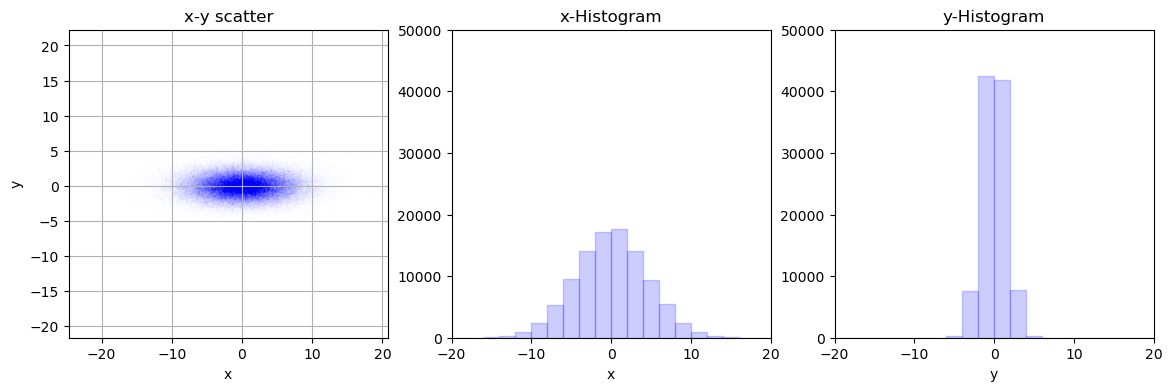

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
standard_plot(fig, axs, pts)
format_plot(np.max(cov), np.max(cov), N//2)
plt.show()

Above I plotted the 2-D scatter plot of the data, as well as the 1-D histograms along each axis.

Perhaps unsurprisingly, the scatter plot looks like an ellipse with the axes aligned with the x- and y-axes.  
The histograms have different heights and widths, because I set the variances at 20 and 2 for x- and y- respectively.  
These histograms can also be thought of as "projections" or shadows of the ellipse on the x- and y-axes.

**Translations:**
* Variance in x (top left diagonal elements) of 20 $\rightarrow$ width of the 2-d scatter in x is $O(20)$
* Variance in y (bottom right diagonal element) of 2 $\rightarrow$ width of the 2-d scatter in x is $O(2)$
* Covariance (off-diagonals) of 0 $\rightarrow$ ellipse has its major/minor axes aligned with the x and y-axes.

If you wanted to check the empirical covariance matches the simulation parameters, use the code below.  
Agreement between real variance and empirical is not that great though unless you start using $N \approx 10^{7}$ (error shrinks as $1/N$).

In [ ]:
test_empirical_covar(pts, cov)

Simulation Covariance:
[[20  0]
 [ 0  2]]
 
Empirically Measured:
[[19.999664  0.003338]
 [ 0.003338  1.996209]]



### Correlated Data I - Fake Correlation / Rotation

In reality, many variables we measure are actually correlated.

I am going to first *simulate* this by rotating my dataset $45^o$ counter-clockwise and plot for visualization purposes.  
Even though this is not a particularly realistic thing to do, there is a mathematical reason for this, so bear with me.

To handle the rotation we can use a standard [rotation matrix](https://en.wikipedia.org/wiki/Rotation_matrix) in 2-D (see the `rotate_pts` function).

In [ ]:
theta = np.pi/4  # 45 degrees
pts_rot = rotate_pts(pts, theta)

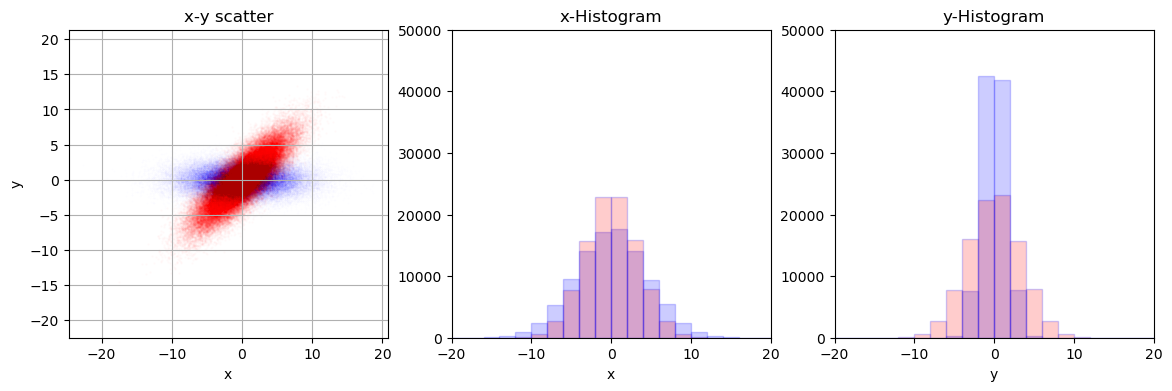

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
standard_plot(fig, axs, pts)
standard_plot(fig, axs, pts_rot, facecolor='r', salpha=0.01)
format_plot(np.max(cov), np.max(cov), N//2)
plt.show()

Above, I'm showing the original data (ellipse and histograms) in blue, while the rotated data is overlayed in red.

As expected, the lengths of the ellipse axes don't actually change with the rotation, but the ellipse is now pointing along the direction set by `theta`.  
The widths of the histograms however *do* change because the ellipse projects onto smaller / larger areas of the axes.  
In this case, the x- and y- histograms should be approximately the same shape because the rotation is by $45^{o}$.

If you check the covariance matrix now, we have in-fact introduced covariance (off-diagonal terms) at the expense of the diagonal terms.

In [ ]:
np.cov(pts_rot, rowvar=False, bias=True)  # rotated points look correlated (non-zero off-diags)

array([[10.994598,  9.001727],
       [ 9.001727, 11.001274]])

### Correlated Data II - Actual Correlation

Now I want to generate *intrinsically correlated* data.

It turns out I can use the same rotation matrix to directly rotate the (original) ncovariance matrix, and it will generate the same distribution as the above.   
Rotating in this case is (still) equivalent to a change of basis.

To [rotate a matrix](https://en.wikipedia.org/wiki/Jacobi_rotation), you need to multiply the rotation to the left and the inverse/transpose to the right (see the `rotate_cov` function).

In [ ]:
cov_rot = rotate_cov(cov, theta)
pts_cor = np.random.multivariate_normal(mean, cov_rot, size=N)

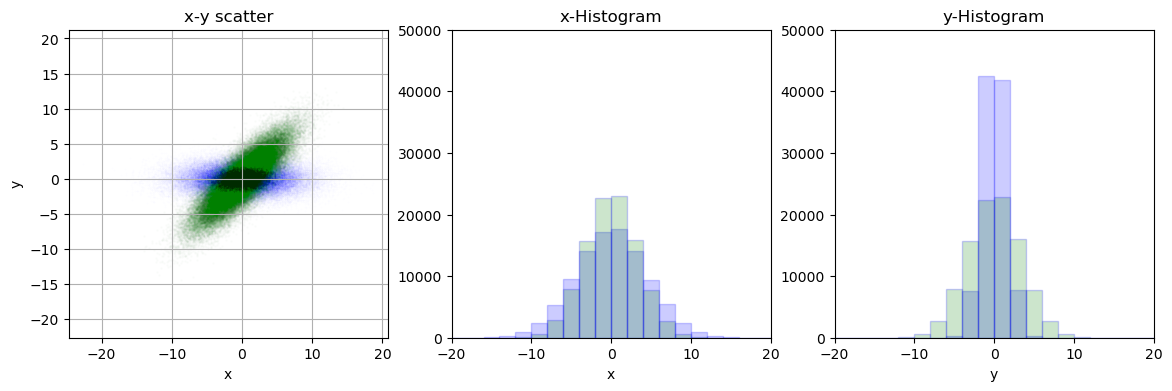

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
standard_plot(fig, axs, pts)
standard_plot(fig, axs, pts_cor, facecolor='g', salpha=0.01)
format_plot(np.max(cov), np.max(cov), N//2)
plt.show()

To wit: the intrinsically correlated data (green) looks like the rotated data.

In fact, plotting both rotated and correlated data in top of each other produce indistinguishable plots, even though they are generated differently and have different values.

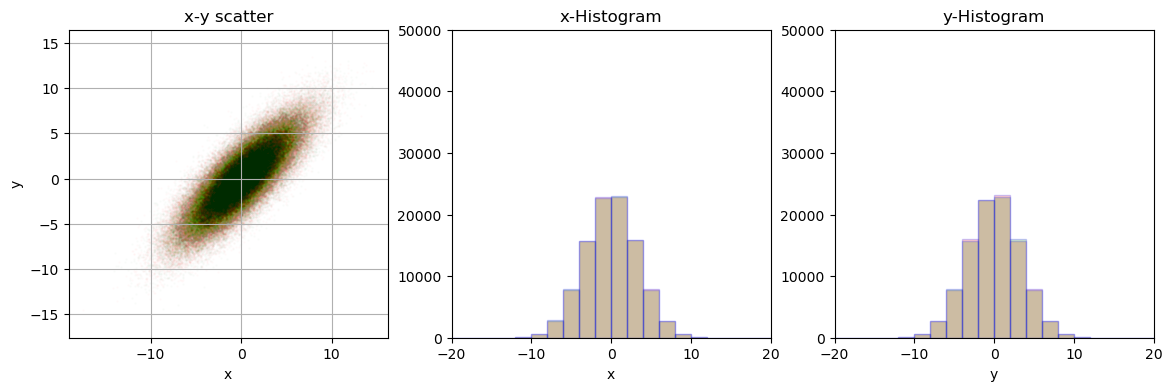

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
standard_plot(fig, axs, pts_rot, facecolor='r', salpha=0.01)
standard_plot(fig, axs, pts_cor, facecolor='g', salpha=0.01)
format_plot(np.max(cov), np.max(cov), N//2)
plt.show()

In [ ]:
test_empirical_covar(pts_rot, cov_rot)

Simulation Covariance:
[[11.  9.]
 [ 9. 11.]]
 
Empirically Measured:
[[10.994598  9.001727]
 [ 9.001727 11.001274]]



In [ ]:
# Proof: the rotated data and intrinsically correlated data are not trivially equal
assert not np.allclose(np.sort(pts_cor, axis=0),
                       np.sort(pts_rot, axis=0),
                       atol=0.5
                       )

>**Punchline:** Uncorrelated data which is (unnaturally) rotated is mathematically equivalent to (genuinely) correlated data.  
There is no meaningful distinction between them.

## Finding Important Relationships

The rotation of a point cloud is not a natural thing to do, but it is a proxy of the reality of data collection.  
Ideally we would collect data in terms of the underlying, uncorrelated variables.  

To illustrate why, we again generate data, say Apple and Tesla, with a covariance matrix.  
Except now we make one of the intrinsic variances way smaller, and *then* we rotate (the matrix in this case).

In [ ]:
N = 10**5
mean = np.array([0, 0])
cov = np.array([[20, 0],
                [0, 2e-9]])

pts = np.random.multivariate_normal(mean, cov, size=N)
cov_rot2 = rotate_cov(cov, theta)
pts_cor2 = np.random.multivariate_normal(mean, cov_rot2, size=N)

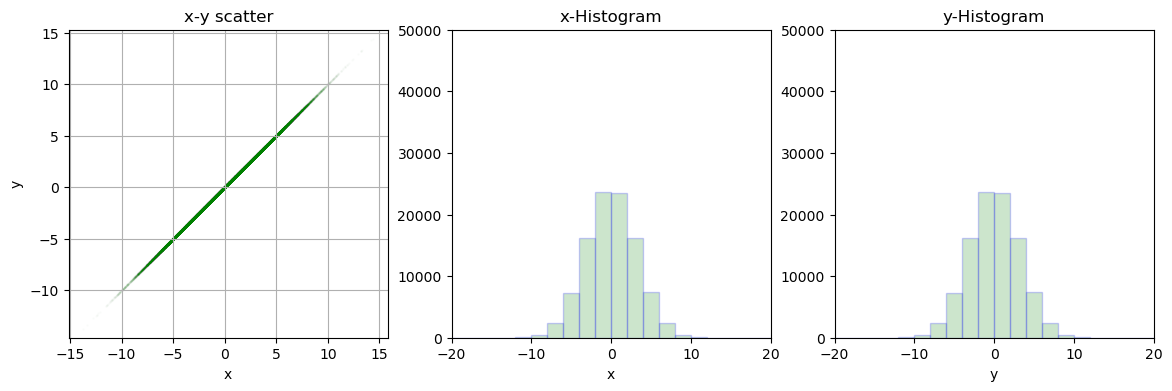

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
standard_plot(fig, axs, pts_cor2, facecolor='g', salpha=0.01)
format_plot(np.max(cov), np.max(cov), N//2)
plt.show()

Notice that the scatter is now effectively a straight line, but the individual histograms are still the same width.  
If you only ever looked at the histograms, you might believe that you need to measure both $x$ and $y$ to fully characterize each data point.  

But the scatter is telling us "no, you only really need to measure one and the other will be about the same value most of the time."  
For all intents and purposes, *this a 1-dimensional system*.  
It's only 2-dimensional because we are measuring $x$ and $y$ separately (because they're easy to measure).  
Moving forward, we could get away with just using their sum.

### Principal Component Analysis (PCA)

It gets harder to make the same visualizations when the raw data has even higher dimensionality.  

For example, say you wanted to analyze all the stocks in the S&P500 for trading purposes.  
The same idea applies: we want to find the ellipsoid that best fits the data, find its largest axes, and ignore the smallest ones.  
This time though, you would need to make a $500$-dimensional ellipsoid (1 dimension per stock).  
                                                                        
I'm clearly not going to plot that, so we need an automated way to do the same analysis.  
At this point I will point out that what we've done so far (mathematically) is [diagonalization](https://en.wikipedia.org/wiki/Diagonalizable_matrix#How_to_diagonalize_a_matrix), for which the `np.linalg.eig` command exists.

In [ ]:
# Diagonalizing the rotated covariance matrix data yields the original covariance matrix
evalues, evectors = np.linalg.eig(cov_rot)
print(f'Uncorrelated Variances / Ellipsoid Axis Lengths: \n {evalues}\n')
print(f'Ellipsoid Axis Directions:\n {evectors}\n')

Uncorrelated Variances / Ellipsoid Axis Lengths: 
 [20.  2.]

Ellipsoid Axis Directions:
 [[ 0.707107 -0.707107]
 [ 0.707107  0.707107]]



In [3]:
import numpy as np

**n.b.** I did this for the covariance matrices where the non-zero entries aren't too small so that I don't have to worry about the numerical stability.

In [4]:
# Scale up to 500 x 500 matrix
var_scale = 1
cov_500 = np.random.rand(500, 500)*var_scale
cov_500 = np.dot(cov_500, cov_500.T)  # needed to make positive semi-definite covariance matrix

evalues_500, evectors_500 = np.linalg.eig(cov_500)
print(f'Uncorrelated Variances / Ellipsoid Axis Lengths: \n {evalues_500}\n')
#print(f'Ellipsoid Axis Directions:\n {evectors}\n')

Uncorrelated Variances / Ellipsoid Axis Lengths: 
 [6.25725422e+04 1.61740762e+02 1.59445580e+02 1.56681207e+02
 1.55932888e+02 1.54027024e+02 1.52095087e+02 1.49349239e+02
 1.49187783e+02 1.47914199e+02 1.46422208e+02 1.44909581e+02
 1.44056166e+02 1.42437274e+02 1.40435483e+02 1.39693644e+02
 1.37594788e+02 1.37146927e+02 1.37340569e+02 1.35710926e+02
 1.34934515e+02 1.34527161e+02 1.33843121e+02 1.32027989e+02
 1.30599001e+02 1.29603954e+02 1.28408053e+02 1.28019656e+02
 1.18288511e+02 1.26394649e+02 1.25710712e+02 1.25239758e+02
 1.24303930e+02 1.19944967e+02 1.20605875e+02 1.21187605e+02
 1.22022046e+02 1.22926971e+02 1.23189963e+02 1.17882803e+02
 1.17780023e+02 1.16557242e+02 1.15470113e+02 1.14085290e+02
 1.14189717e+02 1.13148058e+02 1.11828796e+02 1.11202361e+02
 1.10499667e+02 1.09552623e+02 1.08722044e+02 1.08251145e+02
 1.07548237e+02 1.06963887e+02 1.06658444e+02 1.05587224e+02
 1.04408107e+02 1.04030587e+02 1.03346671e+02 1.02036407e+02
 1.01782695e+02 1.01019172e+02 1.0

In this case I'm just simulating the $500 \times 500$ covariance matrix directly with random entries just to show how it would generalize.  
It's quite straightforward, requiring $\leq 5$ lines.  

If you were inclined, you could actually do this with the real S&P500 stocks by
1. Using `yfinance` to pull historical data.
1. Calculating the empirical covariance matrix with `np.cov`
1. Running `np.linalg.eig` to get the eigenvectors and eigenvalues.

Assuming you did that, congratulations, you basically did half of [Avellaneda & Lee 2008](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1153505) in (presumably) 10 lines of code.  
Specifically, you did the Principal Component Analysis part.  

>**Punchline:** Principal Component Analysis (PCA) is, algorithmically, matrix diagonalization of a covariance matrix.  
> The princpal components (PCs) are the eigenvectors, and their significance is the associate eigenvalue.

where in the paper, the first PC is identified as the market portfolio.  
The other PCs, being orthogonal to the first, represent (ideally) market-neutral portfolios.

In [ ]:
import matplotlib.pyplot as plt

# Sort eigenvalues in descending order
sorted_evalues = np.sort(evalues_500)[::-1]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(sorted_evalues) + 1), sorted_evalues, marker='o')
plt.title('Scree Plot of Eigenvalues (500x500 Covariance Matrix)')
plt.xlabel('Principal Component Number')
plt.ylabel('Eigenvalue (Significance)')
plt.grid(True)
plt.show()


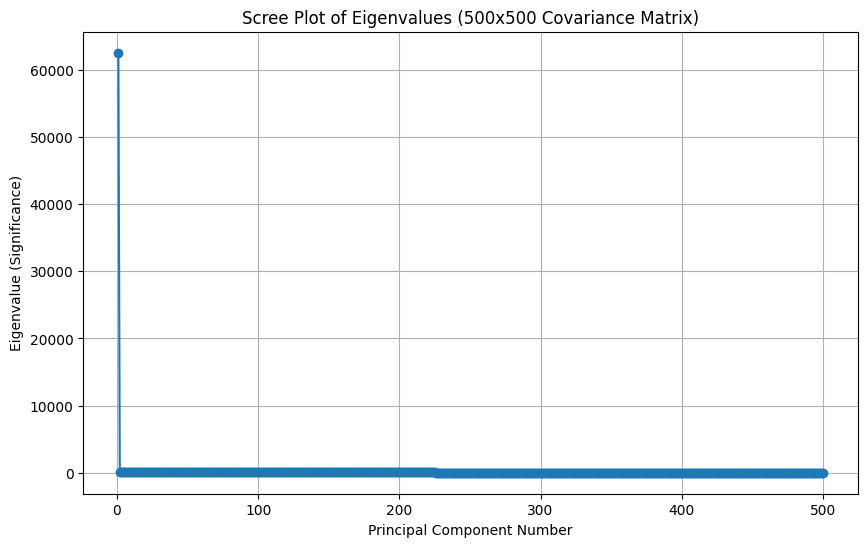

In [6]:
import matplotlib.pyplot as plt

# Sort eigenvalues in descending order
sorted_evalues = np.sort(evalues_500)[::-1]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(sorted_evalues) + 1), sorted_evalues, marker='o')
plt.title('Scree Plot of Eigenvalues (500x500 Covariance Matrix)')
plt.xlabel('Principal Component Number')
plt.ylabel('Eigenvalue (Significance)')
plt.grid(True)
plt.show()


### Pulling Historical Data using `yfinance`

To demonstrate PCA with real-world data, we'll fetch historical stock prices for S&P 500 components using the `yfinance` library.

In [ ]:
# Install yfinance library
!pip install yfinance


In [8]:
import yfinance as yf
import pandas as pd

# For simplicity and to avoid hitting API limits, let's use a small subset of S&P500 tickers
# In a real scenario, you would fetch all 500+ tickers.
# Here, we'll use a few well-known tech stocks as a proxy.
symbols = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'META', 'BRK-B', 'JPM', 'V']

# Define the date range for historical data
start_date = '2020-01-01'
end_date = '2023-01-01'

# Download the adjusted close prices for the selected tickers
data = yf.download(symbols, start=start_date, end=end_date)['Close']

# Display the first few rows of the downloaded data
display(data.head())

/tmp/ipykernel_11499/4165241948.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbols, start=start_date, end=end_date)['Close']
[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,AMZN,BRK-B,GOOGL,JPM,META,MSFT,NVDA,TSLA,V
Date,,,,,,,,,,
2020-01-02,72.333878,94.900497,228.389999,67.873032,118.430298,208.146561,151.829575,5.970755,28.684000,182.431061
2020-01-03,71.630623,93.748497,226.179993,67.517967,116.867462,207.045212,149.938995,5.875186,29.534000,180.980179
2020-01-06,72.201408,95.143997,226.990005,69.317581,116.774521,210.944641,150.326584,5.899825,30.102667,180.588806
2020-01-07,71.861855,95.343002,225.919998,69.183701,114.789314,211.401016,148.955933,5.971252,31.270666,180.111542
2020-01-08,73.017838,94.598503,225.990005,69.676117,115.684776,213.544235,151.328522,5.982451,32.809334,183.194733


Now that we have the historical adjusted close prices, the next step in PCA for financial data is typically to calculate daily returns. This is because returns, rather than absolute prices, are what financial analysts typically work with for volatility and correlation analysis.

In [ ]:
# Calculate daily returns
returns = data.pct_change().dropna()

# Display the first few rows of the returns data
display(returns.head())

In [10]:
# Calculate daily returns
returns = data.pct_change().dropna()

# Calculate the empirical covariance matrix of the returns
cov_matrix = np.cov(returns, rowvar=False)

print("Empirical Covariance Matrix of Returns:")
print(cov_matrix)

Empirical Covariance Matrix of Returns:
[[0.0005413  0.00037989 0.00022417 0.00036959 0.00026294 0.00044875
  0.00041331 0.00058498 0.00054952 0.00031371]
 [0.00037989 0.00060619 0.00015597 0.00036382 0.00017265 0.00046782
  0.00037809 0.00057564 0.00053428 0.00023196]
 [0.00022417 0.00015597 0.00025998 0.00020597 0.00031249 0.00021183
  0.00021654 0.00027485 0.00022389 0.00024386]
 [0.00036959 0.00036382 0.00020597 0.00047296 0.0002554  0.0004671
  0.00039532 0.0005469  0.00044741 0.00029257]
 [0.00026294 0.00017265 0.00031249 0.0002554  0.00056959 0.00026139
  0.00026038 0.0003301  0.00030686 0.00033146]
 [0.00044875 0.00046782 0.00021183 0.0004671  0.00026139 0.00094202
  0.00043532 0.00065146 0.00051589 0.00032274]
 [0.00041331 0.00037809 0.00021654 0.00039532 0.00026038 0.00043532
  0.00047939 0.00059082 0.00049868 0.00031134]
 [0.00058498 0.00057564 0.00027485 0.0005469  0.0003301  0.00065146
  0.00059082 0.00124341 0.00088003 0.00042647]
 [0.00054952 0.00053428 0.00022389 0.0004

In [11]:
# Perform eigenvalue decomposition on the covariance matrix
stock_evalues, stock_evectors = np.linalg.eig(cov_matrix)

print("Eigenvalues (Significance of Principal Components):")
print(stock_evalues)

print("\nEigenvectors (Principal Components, each column is a PC):")
print(stock_evectors)


Eigenvalues (Significance of Principal Components):
[4.59583384e-03 1.18000074e-03 6.16858364e-04 4.05608266e-04
 2.56496768e-04 1.85879961e-04 5.46937296e-05 6.82423950e-05
 1.35016617e-04 1.28618914e-04]

Eigenvectors (Principal Components, each column is a PC):
[[-0.28871877  0.1319747  -0.01347373 -0.04207961  0.2753038  -0.5119399
  -0.11363591  0.2752678  -0.59144502  0.34771337]
 [-0.27865869  0.10632589  0.29357555  0.00585118  0.68860044  0.52813298
   0.00513161  0.02896237  0.15554018  0.21603332]
 [-0.14941754  0.1568833  -0.36413586  0.01990369  0.03522773  0.0629126
   0.8973514  -0.01333343 -0.0968648   0.00847693]
 [-0.26603117  0.19116787  0.02999868  0.04624627  0.14527562 -0.17165651
  -0.02441828  0.5125      0.19717457 -0.7327635 ]
 [-0.19346098  0.20180337 -0.68277735  0.09684353 -0.07467734  0.45056021
  -0.40280664 -0.01796787 -0.25948897 -0.08827746]
 [-0.33373788  0.30848393  0.35124003  0.69881544 -0.40048566  0.05238523
   0.02361089 -0.07565104 -0.03564644 

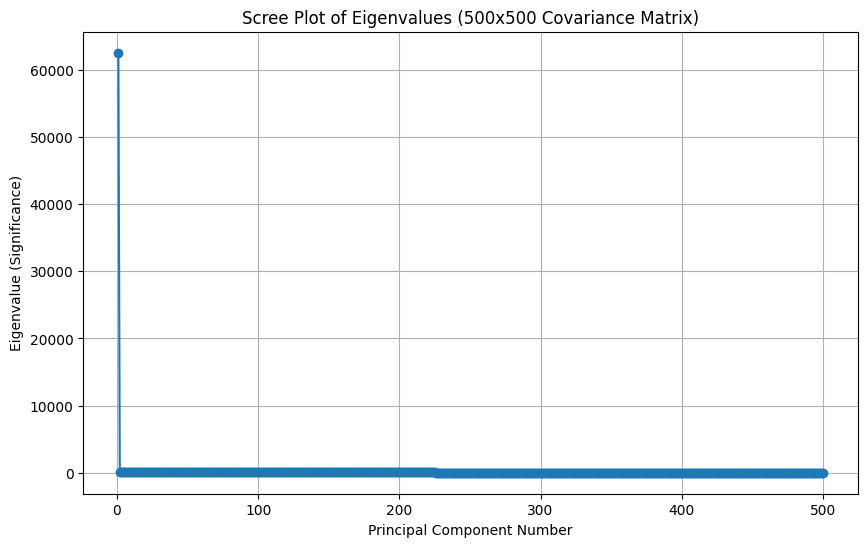

In [12]:
# Sort eigenvalues in descending order
sorted_evalues = np.sort(evalues_500)[::-1]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(sorted_evalues) + 1), sorted_evalues, marker='o')
plt.title('Scree Plot of Eigenvalues (500x500 Covariance Matrix)')
plt.xlabel('Principal Component Number')
plt.ylabel('Eigenvalue (Significance)')
plt.grid(True)
plt.show()

The previous scree plot appears flat because the first eigenvalue from the randomly generated 500x500 covariance matrix is significantly larger than the rest. To better visualize the distribution of the smaller eigenvalues, we can plot them on a logarithmic scale.

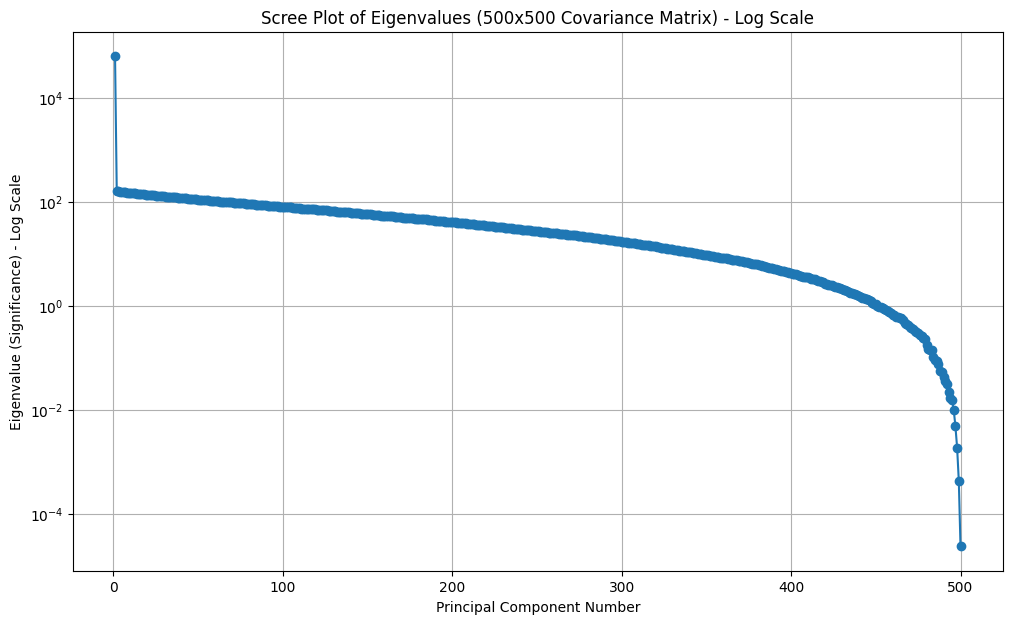

In [13]:
import matplotlib.pyplot as plt

# Sort eigenvalues in descending order (already done, but good to be explicit)
sorted_evalues = np.sort(evalues_500)[::-1]

plt.figure(figsize=(12, 7))
plt.plot(range(1, len(sorted_evalues) + 1), sorted_evalues, marker='o')
plt.title('Scree Plot of Eigenvalues (500x500 Covariance Matrix) - Log Scale')
plt.xlabel('Principal Component Number')
plt.ylabel('Eigenvalue (Significance) - Log Scale')
plt.yscale('log') # Set y-axis to logarithmic scale
plt.grid(True, which="both", ls="-", axis='y') # Add grid for log scale
plt.grid(True, which="major", axis='x')
plt.show()

This logarithmic plot gives a clearer picture of how the eigenvalues decay and allows us to see the relative differences between the smaller principal components. This pattern of a few dominant eigenvalues followed by many smaller ones is typical in randomly generated or complex systems, as well as in real-world financial data, where a few factors explain most of the variance.

## Additonal Material

See [this](https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_iris.html) page on doing PCA with the scikit-learn version of PCA.